# Cloud-Cover Classifier - Balloon ML Payload

Transfer-learned image classifier that labels each downward-looking camera frame by how much
of it is covered by cloud. Runs on the Google Coral Dev Board Micro (Edge TPU) as one of the
two ML payload models; this notebook covers training only. Quantization and Edge TPU
compilation are a separate step downstream.

**Output:** `cloud_classifier.keras` (float model) and `labels.json` (class order).

## 1. Approach

**Task.** Whole-frame classification into three cloud-cover classes: **clear**, **partial**,
**overcast**. One label and one probability vector per frame, which fits the small per-second
telemetry packet and the Edge TPU's int8 classification pipeline.

**Why classification, not segmentation.** The source data ships as per-pixel cloud masks, but
per-pixel output does not compress into the telemetry budget, the U-Net style architectures that
produce it are a poor Edge TPU fit, and the payload only needs a summary of how cloudy the frame
is. We therefore derive a single class label per frame from the masks (see Section 2).

**Why three classes, not four.** An earlier four-class version (clear, scattered, broken,
overcast) spent most of its error budget confusing scattered with broken. Both mean "partly
cloudy"; the boundary between them is an arbitrary cut on a continuous quantity (cloud fraction),
so that confusion was never meaningful. Merging them into a single "partial" class removed the
dominant error source and the mission only needs the clear / partial / overcast distinction.

**Method.** Two-phase transfer learning on a MobileNetV2 backbone pretrained on ImageNet
(MobileNetV2 is Edge TPU compatible). Phase one trains a small classification head on frozen
features; phase two unfreezes the upper backbone and fine-tunes at a low learning rate.
Class imbalance is handled with inverse-frequency class weights.

## 2. Dataset

**Source.** The 95-Cloud dataset (specifically the portion that is additional to 38-Cloud),
derived from Landsat 8 satellite scenes. It is published as a per-pixel cloud **segmentation**
dataset: each 384x384 patch comes with a binary cloud mask.

**Label derivation.** We convert segmentation into classification with `build_cloud_classes.py`:
for each patch we compute the cloud-pixel fraction over the valid (non-margin) area of the mask,
then bin that fraction into a class using thresholds taken from the METAR sky-cover (okta) scale:

| class    | cloud fraction | okta basis        |
|----------|----------------|-------------------|
| clear    | below 12.5%    | 0 to 2 oktas      |
| partial  | 12.5% to 87.5% | 3 to 7 oktas      |
| overcast | above 87.5%    | 8 oktas           |

Using the pixel-accurate masks to define the labels gives more defensible class boundaries than
hand-labelling whole frames by eye.

**Preprocessing choices.**
* **Grayscale.** The flight camera (Himax HM01B0) is monochrome, so we collapse the RGB bands to
  a single luminance channel and drop the near-infrared band. The pretrained backbone expects
  three channels, so the single gray channel is replicated to three at load time.
* **Margin filtering.** Landsat patches at scene edges contain large black no-data regions that
  the camera never produces. We keep only patches that are at least 99% valid (`--min-valid 0.99`)
  so the model is not trained on an artifact it will never see in flight.
* **Class weights.** The classes are imbalanced (the clear and overcast extremes dominate over the
  partial middle), so the loss is weighted by inverse class frequency.

## 3. Mission assumptions and limitations

This model is only valid inside the conditions its training data represents. The following are the
assumptions the cloud classifier carries into the mission, and where it will and will not work.

**3.1 Viewing geometry (camera placement).** The training imagery is satellite nadir view, looking
straight down. The flight camera must therefore be mounted **looking down**, as close to nadir as
the enclosure allows. An oblique or sideways mounting puts the input out of distribution and will
degrade accuracy; a horizon or upward view would not work at all with this model.

**3.2 Altitude and scale gap (the dominant validation risk).** Landsat images from roughly 700 km
at 30 m per pixel; the balloon flies at roughly 30 km. The apparent size, texture, and parallax of
clouds at balloon altitude differ from the satellite scale the model learned on. This is a
simulation-to-reality gap and it is the single largest unknown for this model. It cannot be closed
on paper: it has to be checked against real frames captured in flight. The SD-card frame logging in
the payload exists precisely so this can be validated after the mission, and ideally a short
ground or test-flight capture should be classified before relying on the output.

**3.3 Spectral channels (monochrome versus RGB camera).** We trained on grayscale to match the
current monochrome camera. The natural question is how much an RGB camera would buy us. Honest
expectation: a **modest** improvement, likely in the low single-digit percentage points, and
concentrated on telling bright surfaces apart from bright cloud. Cloud cover is driven mostly by
brightness and texture, which grayscale already captures, so colour adds limited information for
this task. Critically, the channel that *would* help a lot, near-infrared or shortwave (it is how
the original Landsat labels separate snow and ice from cloud), is not available on any consumer RGB
or monochrome camera, so RGB will not solve the snow-versus-cloud ambiguity. The number above is an
estimate, not a measurement. To get a real figure, run the ablation described in Section 8:
regenerate the dataset keeping the three RGB channels and retrain identically; the accuracy delta
is the answer.

**3.4 Illumination and time of day.** Landsat 8 is in a sun-synchronous orbit with an equator
crossing near 10:30 local time, so every training image is daytime under mid-morning sun angles.
The model is therefore valid for **daytime flight with a reasonable sun elevation**. Low-sun
conditions near dawn or dusk (long shadows, low contrast, reddened light) are out of distribution
and accuracy should be expected to drop. Night is moot: a visible-light camera sees nothing useful,
and the model has never seen it.

**3.5 Surface domain.** The global Landsat scenes include snow, ice, and desert, which are bright
surfaces easily mistaken for cloud in grayscale. The mission flies over temperate Bavarian
farmland and forest in daylight, so these confusing surfaces are largely absent from the actual
flight domain even though they exist in the training set. The model may misclassify bright terrain
if it encounters it, but it usually will not encounter it.

## 4. Setup and data loading

In [ ]:
import json 
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("TF", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus if gpus else "NONE (running on CPU - slower but works)")

TF 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [21]:
# config
DATA_DIR   = Path("cloud_classes")   # produced by build_cloud_classes.py (3-class version)
IMG_SIZE   = (224, 224)
BATCH      = 32
SEED       = 1337
EPOCHS_HEAD = 15
EPOCHS_FT   = 40
MODEL_OUT  = "cloud_classifier.keras"
LABELS_OUT = "labels.json" 

In [22]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="training", seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH, color_mode="grayscale", label_mode="int")
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation", seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH, color_mode="grayscale", label_mode="int")

class_names = train_ds.class_names
n = len(class_names)
print("class_names:", class_names)    # expect ['clear', 'overcast', 'partial']
json.dump(class_names, open(LABELS_OUT, "w"))

Found 13335 files belonging to 3 classes.
Using 10668 files for training.
Found 13335 files belonging to 3 classes.
Using 2667 files for validation.
class_names: ['clear', 'overcast', 'partial']


## 5. Class weights (from real counts, keyed by class index)

In [23]:
counts = [len(list((DATA_DIR / c).glob("*.png"))) for c in class_names]
total = sum(counts)
class_weight = {i: total / (n * c) for i, c in enumerate(counts)}
print("counts:", dict(zip(class_names, counts)))
print("class_weight:", {class_names[i]: round(w, 3) for i, w in class_weight.items()})

counts: {'clear': 5488, 'overcast': 4738, 'partial': 3109}
class_weight: {'clear': 0.81, 'overcast': 0.938, 'partial': 1.43}


## 6. Input pipeline: grayscale to 3 channels + MobileNetV2 preprocessing

In [24]:
AUTOTUNE = tf.data.AUTOTUNE

def augment(x, y):                       # x: grayscale [0,255], (224,224,1)
    x = tf.image.random_flip_left_right(x)
    x = tf.image.random_flip_up_down(x)
    x = tf.image.random_brightness(x, max_delta=25.0)
    x = tf.image.random_contrast(x, 0.85, 1.15)
    x = tf.clip_by_value(x, 0.0, 255.0)
    return x, y

def to_model(x, y):                      # gray->3ch + MobileNetV2 preprocess
    x = tf.image.grayscale_to_rgb(x)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    return x, y

# cache the decoded images, THEN augment per-epoch (so augmentation varies each epoch)
train_ds = (train_ds.cache().shuffle(2000)
                    .map(augment, num_parallel_calls=AUTOTUNE)
                    .map(to_model, num_parallel_calls=AUTOTUNE)
                    .prefetch(AUTOTUNE))
val_ds = val_ds.map(to_model, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

## 7. Sanity check: one batch\nConfirm images load and labels look right before a long run.

batch: (32, 224, 224, 3) labels: 0 - 2


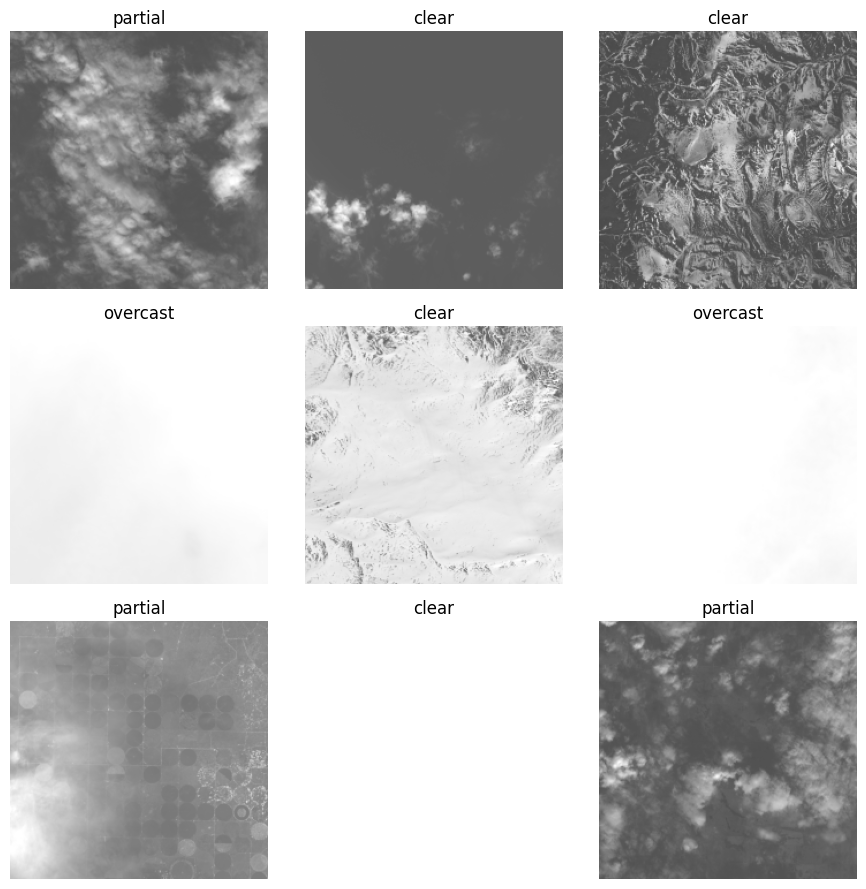

In [25]:
xb, yb = next(iter(train_ds))
print("batch:", xb.shape, "labels:", int(yb.numpy().min()), "-", int(yb.numpy().max()))
plt.figure(figsize=(9, 9))
for i in range(min(9, xb.shape[0])):
    plt.subplot(3, 3, i + 1)
    plt.imshow((xb[i].numpy() + 1) / 2)
    plt.title(class_names[yb[i]]); plt.axis("off")
plt.tight_layout(); plt.show()

## 8. Model and Phase 1 training (frozen backbone + head)

In [26]:
base = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
base.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(n, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d_2  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dropout_2 (Dropout)         (None, 1280)              0         
                                                                 
 dense_2 (Dense)             (None, 3)                 3843      
                                                                 
Total params: 2261827 (8.63 MB)
Trainable params: 3843 (15.

In [27]:
history = model.fit(train_ds, validation_data=val_ds,
                    epochs=EPOCHS_HEAD, class_weight=class_weight)

Epoch 1/15
334/334 [==============================] - 21s 53ms/step - loss: 0.6776 - accuracy: 0.7142 - val_loss: 0.5167 - val_accuracy: 0.7859
Epoch 2/15
  4/334 [..............................] - ETA: 16s - loss: 0.5264 - accuracy: 0.7578

W0000 00:00:1780910318.457742   80232 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267712 bytes after encountering the first element of size 19267712 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


334/334 [==============================] - 17s 50ms/step - loss: 0.5563 - accuracy: 0.7758 - val_loss: 0.5594 - val_accuracy: 0.7578
Epoch 3/15
334/334 [==============================] - 17s 50ms/step - loss: 0.5363 - accuracy: 0.7829 - val_loss: 0.4837 - val_accuracy: 0.7904
Epoch 4/15
334/334 [==============================] - 17s 51ms/step - loss: 0.5174 - accuracy: 0.7912 - val_loss: 0.4777 - val_accuracy: 0.7930
Epoch 5/15
334/334 [==============================] - 17s 51ms/step - loss: 0.5018 - accuracy: 0.8002 - val_loss: 0.5008 - val_accuracy: 0.7923
Epoch 6/15
334/334 [==============================] - 17s 51ms/step - loss: 0.5011 - accuracy: 0.7987 - val_loss: 0.4622 - val_accuracy: 0.8043
Epoch 7/15
334/334 [==============================] - 17s 51ms/step - loss: 0.4999 - accuracy: 0.8014 - val_loss: 0.4748 - val_accuracy: 0.7968
Epoch 8/15
334/334 [==============================] - 18s 52ms/step - loss: 0.4961 - accuracy: 0.8017 - val_loss: 0.4440 - val_accuracy: 0.8226
Epo

## 9. Phase 2 fine-tuning (unfreeze upper backbone, low learning rate)

Phase 1 plateaus once the head has extracted what it can from frozen ImageNet features. Fine-tuning
lets the upper backbone layers adapt to overhead cloud imagery. Three things make this safe:
the learning rate drops 100x so the pretrained weights are nudged rather than destroyed; only the
upper layers unfreeze (early layers detect generic edges that already transfer); and the
BatchNorm layers stay frozen so small batches do not corrupt their running statistics. EarlyStopping
restores the best weights, so the high epoch cap is just a ceiling.

In [28]:
base.trainable = True
FINE_TUNE_AT = 80   # MobileNetV2 has 154 layers; unfreeze from here upFINE_TUNE_AT = 60   # was 100; unfreeze more of the backbone for partial-class capacity
for layer in base.layers[:FINE_TUNE_AT]:
    layer.trainable = False
for layer in base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print("trainable params now:", sum(int(tf.size(w)) for w in model.trainable_weights))

trainable params now: 2016259


In [29]:
early = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True)
history_ft = model.fit(train_ds, validation_data=val_ds,
                       epochs=EPOCHS_FT, class_weight=class_weight, callbacks=[early])

Epoch 1/40
334/334 [==============================] - 29s 73ms/step - loss: 0.4775 - accuracy: 0.8097 - val_loss: 0.4287 - val_accuracy: 0.8249
Epoch 2/40
334/334 [==============================] - 24s 72ms/step - loss: 0.4321 - accuracy: 0.8288 - val_loss: 0.4064 - val_accuracy: 0.8305
Epoch 3/40
334/334 [==============================] - 24s 72ms/step - loss: 0.4099 - accuracy: 0.8370 - val_loss: 0.4114 - val_accuracy: 0.8275
Epoch 4/40
334/334 [==============================] - 24s 72ms/step - loss: 0.3926 - accuracy: 0.8427 - val_loss: 0.3959 - val_accuracy: 0.8328
Epoch 5/40
334/334 [==============================] - 24s 73ms/step - loss: 0.3744 - accuracy: 0.8520 - val_loss: 0.4142 - val_accuracy: 0.8283
Epoch 6/40
334/334 [==============================] - 24s 73ms/step - loss: 0.3614 - accuracy: 0.8582 - val_loss: 0.4051 - val_accuracy: 0.8275
Epoch 7/40
334/334 [==============================] - 25s 74ms/step - loss: 0.3407 - accuracy: 0.8659 - val_loss: 0.3673 - val_accuracy:

## 10. Training curves

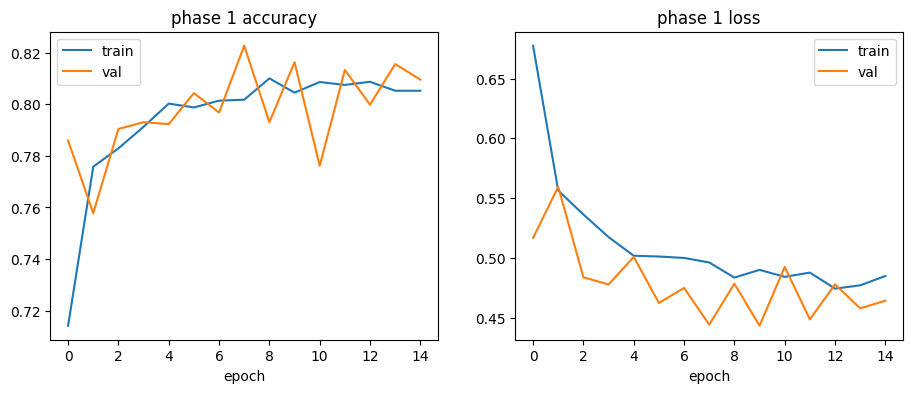

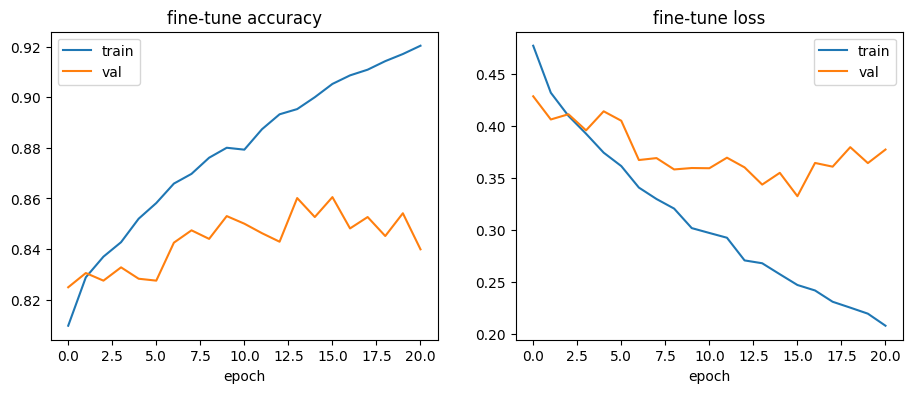

In [30]:
def plot_hist(h, title):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(h["accuracy"], label="train"); ax[0].plot(h["val_accuracy"], label="val")
    ax[0].set_title(title + " accuracy"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(h["loss"], label="train"); ax[1].plot(h["val_loss"], label="val")
    ax[1].set_title(title + " loss"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.show()
plot_hist(history.history, "phase 1")
plot_hist(history_ft.history, "fine-tune")

## 11. Save model and labels

In [31]:
model.save(MODEL_OUT)
print("saved", MODEL_OUT, "and", LABELS_OUT)

saved cloud_classifier.keras and labels.json


## 12. Per-class evaluation

Overall accuracy is misleading when classes are imbalanced. Read the per-class recall and the
confusion matrix: for a cloud-fraction problem most errors should be between neighbouring classes
(clear<->partial, partial<->overcast), which are near-boundary patches that are genuinely
ambiguous. Clear<->overcast errors (the only non-adjacent pair) are the bright-surface confusion
discussed in Section 3.5 and should be rare.

In [32]:
y_true, y_pred = [], []
for xb, yb in val_ds:
    p = model.predict(xb, verbose=0)
    y_true.extend(yb.numpy().tolist())
    y_pred.extend(np.argmax(p, axis=1).tolist())

cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=n).numpy()
print("Confusion matrix (rows=true, cols=pred), order:", class_names)
print(cm)
print("\nPer-class recall:")
for i, c in enumerate(class_names):
    s = cm[i].sum(); rec = cm[i, i] / s if s else 0.0
    print("  %-10s %.3f  (n=%d)" % (c, rec, s))

Confusion matrix (rows=true, cols=pred), order: ['clear', 'overcast', 'partial']
[[1040    6   68]
 [  20  834   97]
 [  89   92  421]]

Per-class recall:
  clear      0.934  (n=1114)
  overcast   0.877  (n=951)
  partial    0.699  (n=602)


### Interpreting the Result
Measured (3-class, fine-tuned): overall 0.83. Recall — clear 0.88, overcast 0.83, partial 0.75. Non-adjacent (clear↔overcast) errors 1.3% of validation, confirming the bright-surface confusion is rare; the bulk of errors are adjacent boundary confusions through the partial class, as expected for binned cloud fraction.

## 13 Int8 quantization for the Edge TPU

The Edge TPU runs only full-integer (int8) models. We quantize with post-training quantization:
a representative sample of training inputs lets the converter pick per-tensor scales. The model is
kept pure (no preprocessing layers) so it compiles cleanly; the grayscale->3ch and [-1,1] scaling
stay external and must be reproduced on-device.

**On-device preprocessing contract (for the coralmicro C++ side):**
1. Resize the camera frame to 224x224.
2. Replicate the single grayscale channel to 3 identical channels.
3. Map each pixel to the model input: take the input tensor's `scale` and `zero_point` (printed
   below), compute `q = round((gray/127.5 - 1)/scale + zero_point)`, clamp to [-128, 127], store int8.
4. Read the output tensor; argmax gives the class index (order in labels.json). Argmax needs no
   dequantization. To recover probabilities, dequantize: `p = (out - zero_point) * scale`.

In [33]:
import random
def representative_dataset():
    per_class = 150
    for c in class_names:
        files = list((DATA_DIR / c).glob("*.png"))
        random.Random(0).shuffle(files)
        for fp in files[:per_class]:
            img = tf.keras.utils.load_img(fp, color_mode="grayscale", target_size=IMG_SIZE)
            arr = tf.keras.utils.img_to_array(img)                      # (224,224,1), [0,255]
            arr = tf.image.grayscale_to_rgb(tf.convert_to_tensor(arr))  # (224,224,3)
            arr = tf.keras.applications.mobilenet_v2.preprocess_input(arr)
            yield [arr[tf.newaxis, ...]]

conv = tf.lite.TFLiteConverter.from_keras_model(model)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
conv.representative_dataset = representative_dataset
conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
conv.inference_input_type = tf.int8
conv.inference_output_type = tf.int8
tflite_model = conv.convert()

with open("cloud_classifier_int8.tflite", "wb") as f:
    f.write(tflite_model)
print("wrote cloud_classifier_int8.tflite,", len(tflite_model), "bytes")

INFO:tensorflow:Assets written to: /tmp/tmpmlmut0jo/assets


INFO:tensorflow:Assets written to: /tmp/tmpmlmut0jo/assets
/home/khess/cubesat-ml/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1780911100.776156   65599 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1780911100.776208   65599 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1780911100.776818   65599 reader.cc:83] Reading SavedModel from: /tmp/tmpmlmut0jo
I0000 00:00:1780911100.790952   65599 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1780911100.791011   65599 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpmlmut0jo
I0000 00:00:1780911100.874392   65599 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1780911101.202950   65599 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpmlmut0jo
I0000 00:00:1780911101.

wrote cloud_classifier_int8.tflite, 2715512 bytes


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1780911150.297028   65599 flatbuffer_export.cc:3851] Skipping runtime version metadata in the model. This will be generated by the exporter.


### Validation: Check Loss of Accuracy

In [34]:
interp = tf.lite.Interpreter(model_content=tflite_model)
interp.allocate_tensors()
ind, outd = interp.get_input_details()[0], interp.get_output_details()[0]
in_scale, in_zp = ind["quantization"]
print("input scale/zero_point:", in_scale, in_zp)   # your C++ needs these

yt, yp = [], []
for images, labels in val_ds:
    for img, lab in zip(images.numpy(), labels.numpy()):
        q = np.round(img / in_scale + in_zp).clip(-128, 127).astype(np.int8)
        interp.set_tensor(ind["index"], q[np.newaxis, ...])
        interp.invoke()
        yp.append(int(np.argmax(interp.get_tensor(outd["index"])[0])))
        yt.append(int(lab))

cm = tf.math.confusion_matrix(yt, yp, num_classes=n).numpy()
acc = np.trace(cm) / cm.sum()
print("\nINT8 accuracy: %.3f  (float was ~0.83)" % acc)
print("Confusion matrix, order:", class_names); print(cm)
for i, c in enumerate(class_names):
    s = cm[i].sum()
    print("  %-10s recall %.3f" % (c, cm[i, i] / s if s else 0))

/home/khess/cubesat-ml/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


input scale/zero_point: 0.007843137718737125 -1

INT8 accuracy: 0.807  (float was ~0.83)
Confusion matrix, order: ['clear', 'overcast', 'partial']
[[882  84 148]
 [  6 856  89]
 [ 64 123 415]]
  clear      recall 0.792
  overcast   recall 0.900
  partial    recall 0.689


## 14. Next steps

1. **Quantize to int8** (post-training quantization with a representative dataset) and convert to
   TFLite. The Edge TPU only runs int8.
2. **Compile for the Edge TPU** with `edgetpu_compiler`, confirming the whole graph maps to the TPU.
3. **Deploy** with the coralmicro C++ SDK: embed the model, capture from the camera, run inference,
   emit the result over UART to the OBC.
4. **Validate against real frames** (Section 3.2). This is the highest-priority check before
   trusting the output in flight.

**Optional RGB ablation (Section 3.3).** To measure rather than estimate the RGB-versus-mono
accuracy gap: regenerate the dataset keeping the three RGB channels (skip the grayscale collapse in
`build_cloud_classes.py`), set `color_mode="rgb"` in the loaders, drop the `grayscale_to_rgb` line
in the pipeline, and retrain with everything else identical. The difference in per-class recall is
the real number to report.